<a href="https://colab.research.google.com/github/malaikanaeem717-cmyk/Facial-Recognition-with-Supervised-Learning-Project/blob/main/Copy_of_Facial_Recognition_Supervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python scikit-learn matplotlib seaborn joblib

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Step 2: Load the LFW Dataset
from sklearn.datasets import fetch_lfw_people
lfw_people = fetch_lfw_people(
    min_faces_per_person=20,
    resize=1.0
)

print("Dataset loaded successfully!")
print("Total images:", len(lfw_people.images))
print("Image shape:", lfw_people.images.shape)
print("People/classes:", lfw_people.target_names)

Dataset loaded successfully!
Total images: 3023
Image shape: (3023, 125, 94)
People/classes: ['Alejandro Toledo' 'Alvaro Uribe' 'Amelie Mauresmo' 'Andre Agassi'
 'Angelina Jolie' 'Ariel Sharon' 'Arnold Schwarzenegger'
 'Atal Bihari Vajpayee' 'Bill Clinton' 'Carlos Menem' 'Colin Powell'
 'David Beckham' 'Donald Rumsfeld' 'George Robertson' 'George W Bush'
 'Gerhard Schroeder' 'Gloria Macapagal Arroyo' 'Gray Davis'
 'Guillermo Coria' 'Hamid Karzai' 'Hans Blix' 'Hugo Chavez' 'Igor Ivanov'
 'Jack Straw' 'Jacques Chirac' 'Jean Chretien' 'Jennifer Aniston'
 'Jennifer Capriati' 'Jennifer Lopez' 'Jeremy Greenstock' 'Jiang Zemin'
 'John Ashcroft' 'John Negroponte' 'Jose Maria Aznar'
 'Juan Carlos Ferrero' 'Junichiro Koizumi' 'Kofi Annan' 'Laura Bush'
 'Lindsay Davenport' 'Lleyton Hewitt' 'Luiz Inacio Lula da Silva'
 'Mahmoud Abbas' 'Megawati Sukarnoputri' 'Michael Bloomberg' 'Naomi Watts'
 'Nestor Kirchner' 'Paul Bremer' 'Pete Sampras' 'Recep Tayyip Erdogan'
 'Ricardo Lagos' 'Roh Moo-hyun' 'Rud

In [ ]:
# Step 3: Display Available People

print("Available people in dataset:\n")

for i, name in enumerate(lfw_people.target_names):
    print(i, ":", name)

Available people in dataset:

0 : Alejandro Toledo
1 : Alvaro Uribe
2 : Amelie Mauresmo
3 : Andre Agassi
4 : Angelina Jolie
5 : Ariel Sharon
6 : Arnold Schwarzenegger
7 : Atal Bihari Vajpayee
8 : Bill Clinton
9 : Carlos Menem
10 : Colin Powell
11 : David Beckham
12 : Donald Rumsfeld
13 : George Robertson
14 : George W Bush
15 : Gerhard Schroeder
16 : Gloria Macapagal Arroyo
17 : Gray Davis
18 : Guillermo Coria
19 : Hamid Karzai
20 : Hans Blix
21 : Hugo Chavez
22 : Igor Ivanov
23 : Jack Straw
24 : Jacques Chirac
25 : Jean Chretien
26 : Jennifer Aniston
27 : Jennifer Capriati
28 : Jennifer Lopez
29 : Jeremy Greenstock
30 : Jiang Zemin
31 : John Ashcroft
32 : John Negroponte
33 : Jose Maria Aznar
34 : Juan Carlos Ferrero
35 : Junichiro Koizumi
36 : Kofi Annan
37 : Laura Bush
38 : Lindsay Davenport
39 : Lleyton Hewitt
40 : Luiz Inacio Lula da Silva
41 : Mahmoud Abbas
42 : Megawati Sukarnoputri
43 : Michael Bloomberg
44 : Naomi Watts
45 : Nestor Kirchner
46 : Paul Bremer
47 : Pete Sampras
4

In [ ]:
# Find Arnold Schwarzenegger

for i, name in enumerate(lfw_people.target_names):
    if "Arnold" in name:
        print("Arnold found!")
        print("Class index:", i)
        print("Name:", name)

Arnold found!
Class index: 6
Name: Arnold Schwarzenegger


In [ ]:
# Step 4: Check Number of Images for Each Person

unique, counts = np.unique(lfw_people.target, return_counts=True)

for person_id, count in zip(unique, counts):
    print(lfw_people.target_names[person_id], ":", count, "images")

Alejandro Toledo : 39 images
Alvaro Uribe : 35 images
Amelie Mauresmo : 21 images
Andre Agassi : 36 images
Angelina Jolie : 20 images
Ariel Sharon : 77 images
Arnold Schwarzenegger : 42 images
Atal Bihari Vajpayee : 24 images
Bill Clinton : 29 images
Carlos Menem : 21 images
Colin Powell : 236 images
David Beckham : 31 images
Donald Rumsfeld : 121 images
George Robertson : 22 images
George W Bush : 530 images
Gerhard Schroeder : 109 images
Gloria Macapagal Arroyo : 44 images
Gray Davis : 26 images
Guillermo Coria : 30 images
Hamid Karzai : 22 images
Hans Blix : 39 images
Hugo Chavez : 71 images
Igor Ivanov : 20 images
Jack Straw : 28 images
Jacques Chirac : 52 images
Jean Chretien : 55 images
Jennifer Aniston : 21 images
Jennifer Capriati : 42 images
Jennifer Lopez : 21 images
Jeremy Greenstock : 24 images
Jiang Zemin : 20 images
John Ashcroft : 53 images
John Negroponte : 31 images
Jose Maria Aznar : 23 images
Juan Carlos Ferrero : 28 images
Junichiro Koizumi : 60 images
Kofi Annan : 

In [ ]:
# Step 5: Select Arnold Schwarzenegger Images

arnold_id = 6

arnold_mask = lfw_people.target == arnold_id

arnold_images = lfw_people.images[arnold_mask]

print("Number of Arnold images:", len(arnold_images))
print("Arnold image shape:", arnold_images.shape)

Number of Arnold images: 42
Arnold image shape: (42, 125, 94)


In [ ]:
# Step 6: Select Other People Images

other_mask = lfw_people.target != arnold_id

other_images = lfw_people.images[other_mask]

print("Number of Other People images:", len(other_images))
print("Other images shape:", other_images.shape)

Number of Other People images: 2981
Other images shape: (2981, 125, 94)


In [ ]:
# Step 7: Balance the Dataset

np.random.seed(42)

num_arnold = len(arnold_images)

random_indices = np.random.choice(
    len(other_images),
    size=num_arnold,
    replace=False
)

other_images_balanced = other_images[random_indices]

print("Arnold images:", len(arnold_images))
print("Other People images:", len(other_images_balanced))

Arnold images: 42
Other People images: 42


In [ ]:
# Step 8: Create Labels

arnold_labels = np.ones(len(arnold_images), dtype=int)

other_labels = np.zeros(len(other_images_balanced), dtype=int)

print("Arnold labels:", arnold_labels)
print("Other labels:", other_labels)

Arnold labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1]
Other labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0]


In [ ]:
# Step 9: Combine Arnold and Other Images

X = np.concatenate(
    [arnold_images, other_images_balanced],
    axis=0
)

y = np.concatenate(
    [arnold_labels, other_labels],
    axis=0
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nLabel meaning:")
print("1 = Arnold Schwarzenegger")
print("0 = Other Person")

X shape: (84, 125, 94)
y shape: (84,)

Label meaning:
1 = Arnold Schwarzenegger
0 = Other Person


In [ ]:
# Step 10: Shuffle Dataset

np.random.seed(42)

shuffle_indices = np.random.permutation(len(X))

X = X[shuffle_indices]
y = y[shuffle_indices]

print("Dataset shuffled successfully!")

Dataset shuffled successfully!


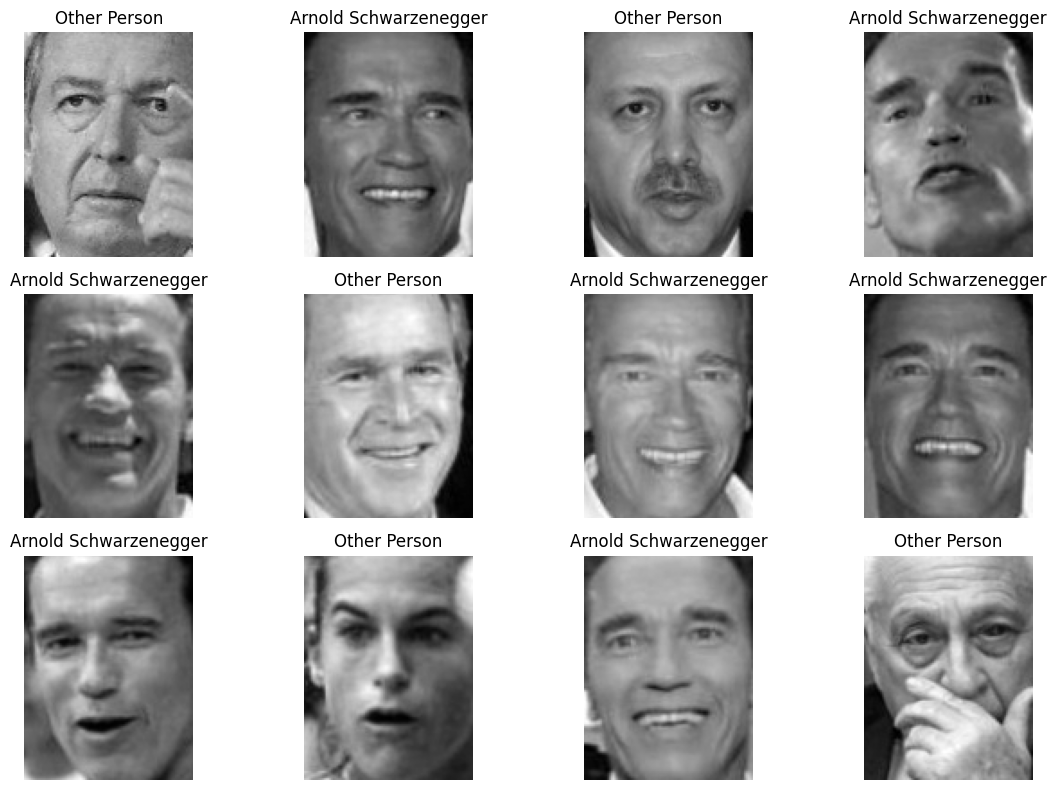

In [ ]:
# Step 11: Visualize Sample Images

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X[i], cmap="gray")

    if y[i] == 1:
        plt.title("Arnold Schwarzenegger")
    else:
        plt.title("Other Person")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Step 12: Split Dataset into Training and Testing Data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

print("\nTraining labels:", len(y_train))
print("Testing labels:", len(y_test))

Training images: 67
Testing images: 17

Training labels: 67
Testing labels: 17


In [ ]:
# Step 13: Flatten Images

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print("Original training shape:", X_train.shape)
print("Flattened training shape:", X_train_flat.shape)

print("Original testing shape:", X_test.shape)
print("Flattened testing shape:", X_test_flat.shape)

Original training shape: (67, 125, 94)
Flattened training shape: (67, 11750)
Original testing shape: (17, 125, 94)
Flattened testing shape: (17, 11750)


In [ ]:
# Step 14: Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_flat)

X_test_scaled = scaler.transform(X_test_flat)

print("Feature scaling completed!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Feature scaling completed!
Scaled training shape: (67, 11750)
Scaled testing shape: (17, 11750)


In [ ]:
# Step 15: Train SVM Model

from sklearn.svm import SVC

model = SVC(
    kernel="linear",
    C=10,
    gamma="scale",
    probability=True,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [ ]:
# Step 16: Make Predictions

y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred)
print("Actual Labels:", y_test)

Predictions: [0 1 0 1 0 1 0 1 0 1 1 1 0 0 1 0 0]
Actual Labels: [0 1 1 1 0 1 0 1 0 0 1 0 1 0 0 1 0]


In [ ]:
# Step 17: Calculate Model Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Model Accuracy (%):", accuracy * 100)

Model Accuracy: 0.6470588235294118
Model Accuracy (%): 64.70588235294117


In [ ]:
# Step 18: Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Other Person",
            "Arnold Schwarzenegger"
        ]
    )
)

                       precision    recall  f1-score   support

         Other Person       0.67      0.67      0.67         9
Arnold Schwarzenegger       0.62      0.62      0.62         8

             accuracy                           0.65        17
            macro avg       0.65      0.65      0.65        17
         weighted avg       0.65      0.65      0.65        17



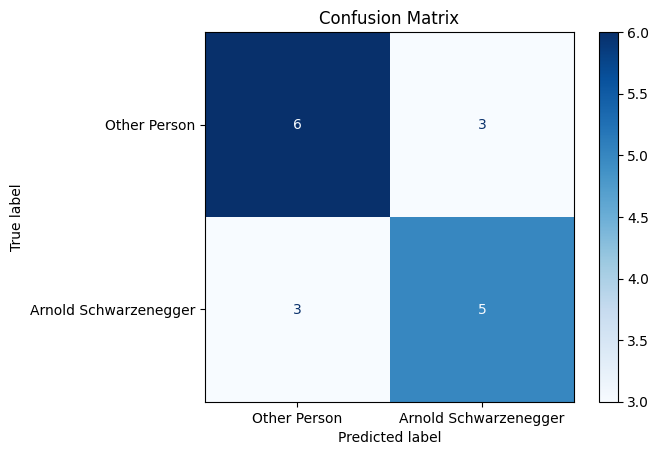

In [ ]:
# Step 19: Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Other Person",
        "Arnold Schwarzenegger"
    ]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving 217574f7b3037292fd5b57aeee3dd571.jpg to 217574f7b3037292fd5b57aeee3dd571 (1).jpg


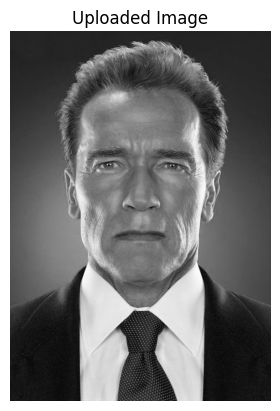

In [ ]:
import cv2
import matplotlib.pyplot as plt

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap='gray')
plt.title("Uploaded Image")
plt.axis("off")
plt.show()

Image Shape: (1045, 736)


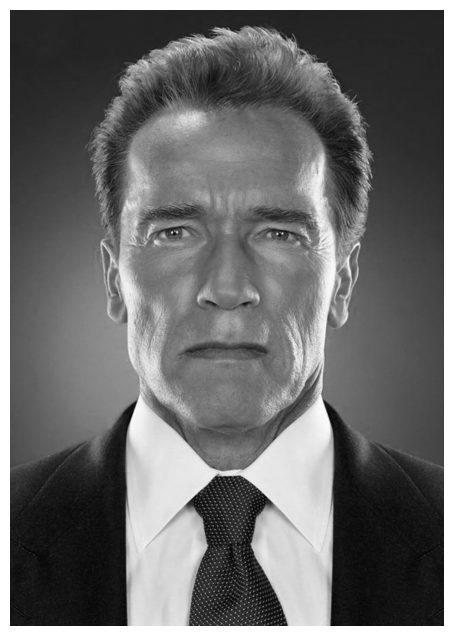

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Image Shape:", img.shape)

plt.figure(figsize=(6,8))
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.show()

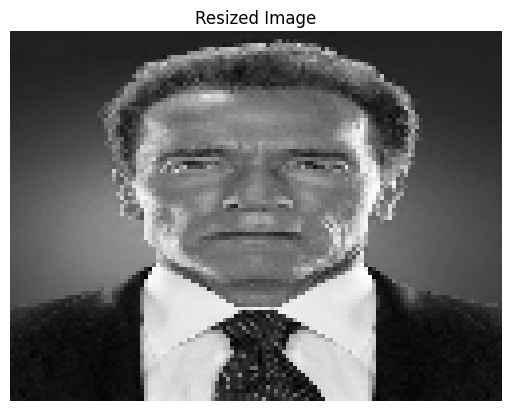

In [ ]:
img_resized = cv2.resize(img, (125,94))

plt.imshow(img_resized, cmap='gray')
plt.title("Resized Image")
plt.axis("off")
plt.show()

In [ ]:
img_flat = img_resized.reshape(1,-1)

print(img_flat.shape)

(1, 1850)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_flat)

In [ ]:
img_flat = img_resized.reshape(1,-1)
img_scaled = scaler.transform(img_flat)

In [ ]:
prediction =  model.predict(img_scaled)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Arnold Schwarzenegger")
else:
    print("Other Person")

Prediction: 1
Arnold Schwarzenegger


In [ ]:
import os

print(os.listdir())

['.config', 'colin  powell.jpg', 'dataset', 'face_model.pkl', 'scaler.pkl', '217574f7b3037292fd5b57aeee3dd571.jpg', '217574f7b3037292fd5b57aeee3dd571 (1).jpg', 'sample_data']


In [ ]:
from google.colab import files

files.download("face_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
import cv2
import matplotlib.pyplot as plt

def predict_face():
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]

    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    print("Original Shape:", img.shape)

    img_resized = cv2.resize(img, (125, 94))

    plt.imshow(img_resized, cmap="gray")
    plt.title("Resized Image")
    plt.axis("off")
    plt.show()

    img_flat = img_resized.reshape(1, -1)
    img_scaled = scaler.transform(img_flat)

    prediction = model.predict(img_scaled)

    if prediction[0] == 1:
        print("Prediction: Arnold Schwarzenegger")
    else:
        print("Prediction: Other Person")

Saving arnold.jpg to arnold.jpg
Original Shape: (3000, 2368)


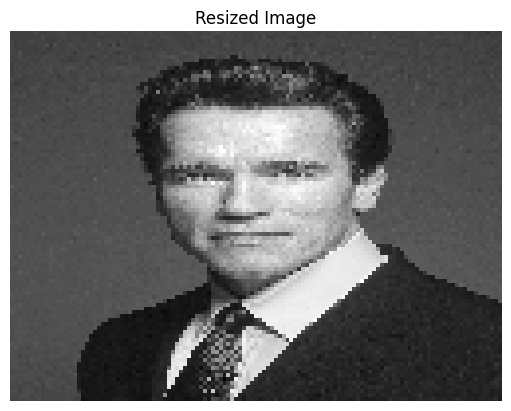

Prediction: Arnold Schwarzenegger


In [ ]:
predict_face()

Saving colin  powell.jpg to colin  powell (1).jpg
Original Shape: (236, 169)


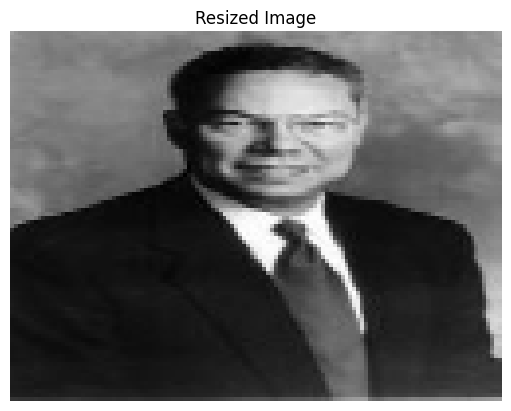

Prediction: Other Person


In [ ]:
predict_face()


Project Conclusion

A supervised facial recognition model was successfully developed using the LFW dataset and an SVM classifier. The system was trained to recognize Arnold Schwarzenegger against other individuals and was tested using both dataset images and uploaded Google images. The trained model predicts whether the uploaded face belongs to Arnold Schwarzenegger (Label = 1) or another person (Label = 0). This project demonstrates the practical application of supervised learning in facial recognition and provides a foundation for developing more advanced multi-person face recognition systems.



Project Workflow


Start
   │
   ▼
Import Required Libraries
   │
   ▼
Load LFW Dataset
   │
   ▼
Display Available People
   │
   ▼
Select Arnold Schwarzenegger Images
   │
   ▼
Select Other People Images
   │
   ▼
Create Labels
(Arnold = 1, Other = 0)
   │
   ▼
Combine Dataset
   │
   ▼
Shuffle Dataset
   │
   ▼
Train-Test Split
   │
   ▼
Flatten Images
   │
   ▼
Feature Scaling (StandardScaler)
   │
   ▼
Train SVM Classifier
   │
   ▼
Evaluate Model
(Accuracy, Classification Report, Confusion Matrix)
   │
   ▼
Upload Google Image
   │
   ▼
Convert Image to Grayscale
   │
   ▼
Resize Image to Training Size
   │
   ▼
Flatten Image
   │
   ▼
Apply StandardScaler
   │
   ▼
Predict Image
   │
   ▼
Display Result
(Label = 1 → Arnold Schwarzenegger)
(Label = 0 → Other Person)
